<a href="https://colab.research.google.com/github/CKimau/CLT_Confidence_intervals/blob/main/phase3project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3 Project

# Beginning

### Business Problem:

#### Enhancing Music Discovery and User Retention through Data-Driven music selection ststem System Optimization


## Overview

![image.png](attachment:image.png)

## Business and Data Understanding
To identify the music genres most likely to engage and retain first-time users by leveraging insights from genre popularity and audio feature analysis.
Understand the diversity of preferences to create a balanced onboarding experience for a wide audience.

The dataset contains information on songs, including attributes like genre, tempo, loudness, and energy. It combines audio features and metadata, enabling analysis of genre appeal and listener preferences.

In [ ]:
pip install --upgrade matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Stats and explainability
from scipy import stats

# General utilities
import os
from datetime import datetime


In [ ]:
# Loading the Dataset
file_path = r"C:\Users\chris.mutuku\OneDrive - Skanem AS\Desktop\Phase3Project\dataset.csv"

# Load the dataset
data = pd.read_csv(file_path)


In [ ]:
# Displaying basic information about the dataset
data_info = data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_genre         456 non-null    object 
 1   duration_ms         456 non-null    int64  
 2    danceability       456 non-null    object 
 3    key                456 non-null    float64
 4   tempo               456 non-null    float64
 5    time_signature     456 non-null    int64  
 6   liveness            456 non-null    float64
 7   loudness            456 non-null    float64
 8    mode               456 non-null    int64  
 9    valence            456 non-null    object 
 10   speechiness        456 non-null    float64
 11   instrumentalness   456 non-null    float64
 12   acousticness       456 non-null    float64
dtypes: float64(7), int64(3), object(3)
memory usage: 46.4+ KB


In [ ]:
data_head = data.head()

data_head

,track_genre,duration_ms,danceability,key,tempo,time_signature,liveness,loudness,mode,valence,speechiness,instrumentalness,acousticness
0,detroit-techno,246602,0.242,5.825,126.592234,5,0.154509,-11.085944,499,0.0306,0.536,0.970,0.850
1,minimal-techno,368863,0.313,5.470,124.747970,5,0.135463,-9.771710,529,0.0235,0.497,0.975,0.829
2,chicago-house,366854,0.534,5.832,123.922680,4,0.137569,-9.149466,498,0.0316,0.475,0.967,0.618
3,breakbeat,321762,0.193,5.640,133.030213,5,0.220316,-6.034380,592,0.0297,0.612,0.963,0.509
4,iranian,319710,-,5.135,114.769364,5,0.192051,-13.080343,547,-,0.918,0.999,0.996


In [ ]:
## Detect duplicate rows:
data.duplicated().sum()


3

In [ ]:
##checking duplicate values
data.drop_duplicates(inplace=True)


In [ ]:
# Checking for outliers or invalid ranges (example for duration_ms)
data = data[data['duration_ms'] >= 0]  # Remove any negative durations

In [ ]:
# Converting track_genre to categorical
data['track_genre'] = data['track_genre'].astype('category')

In [ ]:
from sklearn.preprocessing import StandardScaler

# Columns to scale
columns_to_scale = ['danceability', 'loudness', 'speechiness',
                    'acousticness', 'instrumentalness', 'liveness',
                    'valence', 'tempo']


columns_to_scale = [col for col in columns_to_scale if col in data.columns]

# Apply StandardScaler
scaler = StandardScaler()
data[columns_to_scale] = scaler.fit_transform(data[columns_to_scale])


In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 453 entries, 0 to 455
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   track_genre         453 non-null    category
 1   duration_ms         453 non-null    int64   
 2    danceability       453 non-null    object  
 3    key                453 non-null    float64 
 4   tempo               453 non-null    float64 
 5    time_signature     453 non-null    int64   
 6   liveness            453 non-null    float64 
 7   loudness            453 non-null    float64 
 8    mode               453 non-null    int64   
 9    valence            453 non-null    object  
 10   speechiness        453 non-null    float64 
 11   instrumentalness   453 non-null    float64 
 12   acousticness       453 non-null    float64 
dtypes: category(1), float64(7), int64(3), object(2)
memory usage: 51.4+ KB
None


# EDA

In [ ]:
# Basic descriptive statistics for numerical columns
data.describe()

# Summary statistics for categorical columns
data.describe(include=['object', 'category'])


,track_genre,danceability,valence
count,453,453,453
unique,114,335,309
top,indie-pop,-,-
freq,4,9,12


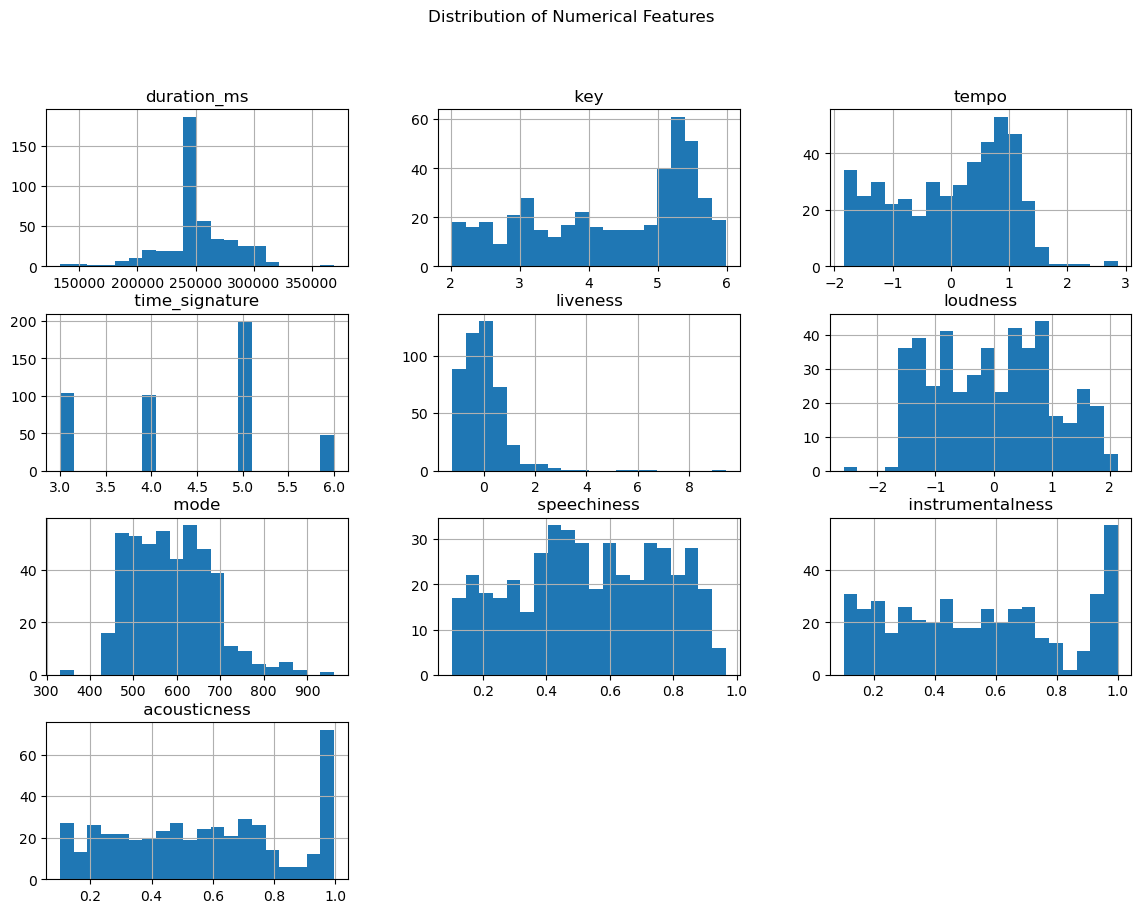

In [ ]:
# Plot histograms for continuous variables
num_cols = data.select_dtypes(include=[np.number]).columns
data[num_cols].hist(bins=20, figsize=(14, 10))
plt.suptitle("Distribution of Numerical Features")
plt.show()


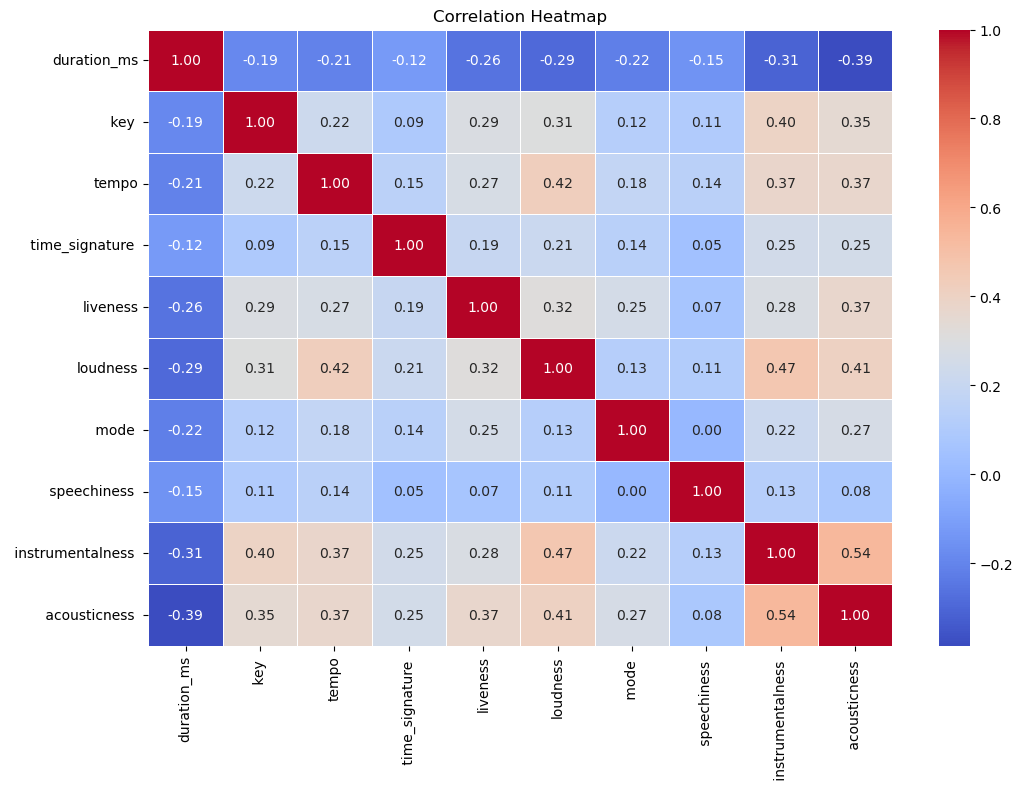

In [ ]:
# Calculating correlation matrix
corr_matrix = data[num_cols].corr()

# Plot heatmap for correlations
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


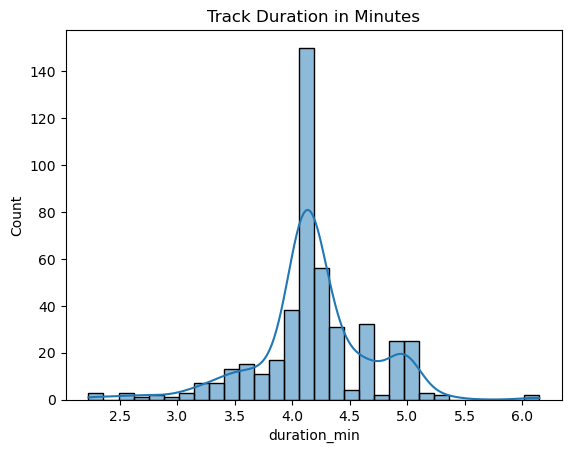

In [ ]:
data['duration_min'] = data['duration_ms'] / 60000
sns.histplot(data['duration_min'], kde=True, bins=30)
plt.title("Track Duration in Minutes")
plt.show()


# Split the Data

In [ ]:
print(y.value_counts())


track_genre
acoustic             0
punk                 0
progressive-house    0
power-pop            0
pop-film             0
                    ..
folk                 0
emo                  0
electronic           0
electro              0
world-music          0
Name: count, Length: 114, dtype: int64


In [ ]:
class_counts = y.value_counts()
sparse_classes = class_counts[class_counts < 2].index
data = data[~data['track_genre'].isin(sparse_classes)]


In [ ]:
print(X.shape)
print(y.shape)


(0, 13)
(0,)


In [ ]:
class_counts = y.value_counts()
print(class_counts)

track_genre
acoustic             0
punk                 0
progressive-house    0
power-pop            0
pop-film             0
                    ..
folk                 0
emo                  0
electronic           0
electro              0
world-music          0
Name: count, Length: 114, dtype: int64


In [ ]:
print(X_train.dtypes)

duration_ms                      float64
 danceability                      int32
 key                             float64
tempo                            float64
 time_signature                    int64
liveness                         float64
loudness                         float64
 mode                              int64
 valence                           int32
 speechiness                     float64
 instrumentalness                float64
 acousticness                    float64
duration_min                     float64
track_genre_Other     Sparse[float64, 0]
track_genre_Other     Sparse[float64, 0]
track_genre                     category
dtype: object


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Identifying categorical columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns


In [ ]:
# Applying OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
encoded_train = encoder.fit_transform(X_train[categorical_cols])
encoded_test = encoder.transform(X_test[categorical_cols])

In [ ]:
# Creating DataFrames with encoded categorical columns
encoded_train_df = pd.DataFrame.sparse.from_spmatrix(encoded_train, columns=encoder.get_feature_names_out(categorical_cols), index=X_train.index)
encoded_test_df = pd.DataFrame.sparse.from_spmatrix(encoded_test, columns=encoder.get_feature_names_out(categorical_cols), index=X_test.index)

In [ ]:
# Droping original categorical columns from X_train and X_test
X_train = X_train.drop(columns=categorical_cols)
X_test = X_test.drop(columns=categorical_cols)

In [ ]:
# Concatenating encoded columns back with remaining data
X_train = pd.concat([X_train, encoded_train_df], axis=1)
X_test = pd.concat([X_test, encoded_test_df], axis=1)

# Verify that all columns are now numeric
print(X_train.dtypes)
print(X_test.dtypes)

duration_ms                      float64
 danceability                      int32
 key                             float64
tempo                            float64
 time_signature                    int64
liveness                         float64
loudness                         float64
 mode                              int64
 valence                           int32
 speechiness                     float64
 instrumentalness                float64
 acousticness                    float64
duration_min                     float64
track_genre_Other     Sparse[float64, 0]
track_genre_Other     Sparse[float64, 0]
track_genre_Other     Sparse[float64, 0]
dtype: object
duration_ms                      float64
 danceability                      int32
 key                             float64
tempo                            float64
 time_signature                    int64
liveness                         float64
loudness                         float64
 mode                              int64
 v

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (335, 16)
y_train shape: (335,)


In [ ]:
# Check the column names
print(data.columns)

# Drop unnecessary columns
columns_to_drop = ['Unnamed: 0', 'track_id']
data.drop(columns=[col for col in columns_to_drop if col in data.columns], inplace=True)

# Verify that the columns were dropped
print(data.columns)


Index(['track_genre', 'duration_ms', ' danceability ', ' key ', 'tempo',
       ' time_signature ', 'liveness', 'loudness', ' mode ', ' valence ',
       ' speechiness ', ' instrumentalness ', ' acousticness ',
       'duration_min'],
      dtype='object')
Index(['track_genre', 'duration_ms', ' danceability ', ' key ', 'tempo',
       ' time_signature ', 'liveness', 'loudness', ' mode ', ' valence ',
       ' speechiness ', ' instrumentalness ', ' acousticness ',
       'duration_min'],
      dtype='object')


In [ ]:
# Drop track name columns (assuming they are not useful for your model)
track_name_cols = [col for col in data.columns if 'track_name' in col]
data.drop(columns=track_name_cols, inplace=True)

# Check the resulting columns
print(data.columns)


Index(['track_genre', 'duration_ms', ' danceability ', ' key ', 'tempo',
       ' time_signature ', 'liveness', 'loudness', ' mode ', ' valence ',
       ' speechiness ', ' instrumentalness ', ' acousticness ',
       'duration_min'],
      dtype='object')


# Classification Model

In [ ]:

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

In [ ]:

# Use sparse matrix to create DataFrame
encoded_train_df = pd.DataFrame.sparse.from_spmatrix(
    encoded_train,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)

encoded_test_df = pd.DataFrame.sparse.from_spmatrix(
    encoded_test,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)


In [ ]:
# Apply OneHotEncoding to categorical columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)  # Keep sparse matrix format
encoded_train = encoder.fit_transform(X_train[categorical_cols])
encoded_test = encoder.transform(X_test[categorical_cols])

# Convert sparse matrix to DataFrame, but only if necessary
encoded_train_df = pd.DataFrame.sparse.from_spmatrix(encoded_train, columns=encoder.get_feature_names_out(categorical_cols), index=X_train.index)
encoded_test_df = pd.DataFrame.sparse.from_spmatrix(encoded_test, columns=encoder.get_feature_names_out(categorical_cols), index=X_test.index)

# Drop original categorical columns and concatenate the encoded columns
X_train = X_train.drop(columns=categorical_cols).join(encoded_train_df)
X_test = X_test.drop(columns=categorical_cols).join(encoded_test_df)

# Check that all columns are numeric now
print(X_train.dtypes)


duration_ms                      float64
 danceability                      int32
 key                             float64
tempo                            float64
 time_signature                    int64
liveness                         float64
loudness                         float64
 mode                              int64
 valence                           int32
 speechiness                     float64
 instrumentalness                float64
 acousticness                    float64
duration_min                     float64
track_genre_Other     Sparse[float64, 0]
track_genre_Other     Sparse[float64, 0]
track_genre_Other     Sparse[float64, 0]
dtype: object


In [ ]:
threshold = 100  # Categories with fewer than 100 occurrences will be replaced by "Other"
for col in categorical_cols:
    value_counts = X_train[col].value_counts()
    rare_categories = value_counts[value_counts < threshold].index
    X_train[col] = X_train[col].replace(rare_categories, 'Other')
    X_test[col] = X_test[col].replace(rare_categories, 'Other')


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Apply LabelEncoder to categorical columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

encoder = LabelEncoder()

# Apply encoding to each categorical column
for col in categorical_cols:
    X_train[col] = encoder.fit_transform(X_train[col])
    X_test[col] = encoder.transform(X_test[col])

# Verify that encoding was applied successfully
print(X_train.head())


      duration_ms   danceability    key      tempo   time_signature   \
284   26372.54597              10  4.906 -1.136347                 3   
326   22202.01869              10  4.179  0.349636                 5   
3    235455.90700               1  5.738  1.065180                 5   
18   225430.86300              10  5.054 -0.321635                 5   
151   32103.71476              10  3.119  0.641248                 3   

     liveness  loudness   mode    valence    speechiness    instrumentalness   \
284  0.430218 -1.479180     573         10          0.467               0.440   
326 -1.245124  0.371546     656         10          0.871               0.606   
3    0.847867  1.578495     641         10          0.304               0.880   
18   9.435923  0.592804     719         10          0.965               0.188   
151 -0.691598 -1.239142     589         10          0.721               0.121   

      acousticness   duration_min  track_genre_Other  track_genre_Other  \
284  

In [ ]:
# Set a threshold for rare categories
threshold = 2  # Minimum number of occurrences for categories to be kept
for col in categorical_cols:
    value_counts = X_train[col].value_counts()
    rare_categories = value_counts[value_counts < threshold].index
    X_train[col] = X_train[col].replace(rare_categories, 'Other')
    X_test[col] = X_test[col].replace(rare_categories, 'Other')

# Apply LabelEncoder to reduced categorical columns
encoder = LabelEncoder()
for col in categorical_cols:
    X_train[col] = encoder.fit_transform(X_train[col])
    X_test[col] = encoder.transform(X_test[col])

# Check the result
print(X_train.head())


      duration_ms   danceability    key      tempo   time_signature   \
284   26372.54597              10  4.906 -1.136347                 3   
326   22202.01869              10  4.179  0.349636                 5   
3    235455.90700               1  5.738  1.065180                 5   
18   225430.86300              10  5.054 -0.321635                 5   
151   32103.71476              10  3.119  0.641248                 3   

     liveness  loudness   mode    valence    speechiness    instrumentalness   \
284  0.430218 -1.479180     573         10          0.467               0.440   
326 -1.245124  0.371546     656         10          0.871               0.606   
3    0.847867  1.578495     641         10          0.304               0.880   
18   9.435923  0.592804     719         10          0.965               0.188   
151 -0.691598 -1.239142     589         10          0.721               0.121   

      acousticness   duration_min  track_genre_Other  track_genre_Other  \
284  

In [ ]:

# Function to plot category distributions
def plot_categorical_distributions(data, columns, title_suffix=""):
    for col in columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(data[col], palette="viridis")
        plt.title(f"Distribution of {col} {title_suffix}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

In [ ]:
def plot_categorical_distributions(data, columns, title_suffix=""):
    for col in columns:
        if col in data.columns:  # Ensure the column exists
            plt.figure(figsize=(8, 5))
            sns.countplot(x=data[col], palette="viridis")
            plt.title(f"Distribution of {col} {title_suffix}")
            plt.xlabel(col)
            plt.ylabel("Count")
            plt.xticks(rotation=45)
            plt.show()


In [ ]:
print("Columns to plot:", categorical_cols)
print("Data preview:")
print(X_train[categorical_cols].head())


Columns to plot: Index([], dtype='object')
Data preview:
Empty DataFrame
Columns: []
Index: [284, 326, 3, 18, 151]


In [ ]:
for col in categorical_cols:
    print(f"Value counts for {col}:\n{X_train[col].value_counts()}")


In [ ]:
for col in categorical_cols:
    if col in X_train.columns:
        counts = X_train[col].value_counts()
        if not counts.empty:
            plt.figure(figsize=(8, 5))
            sns.barplot(x=counts.index, y=counts.values, palette="viridis")
            plt.title(f"Distribution of {col} (Train)")
            plt.xlabel(col)
            plt.ylabel("Count")
            plt.xticks(rotation=45)
            plt.show()
        else:
            print(f"No data to plot for column '{col}'!")


In [ ]:
for col in categorical_cols:
    print(f"Processing column: {col}")
    print(X_train[col].head())


In [ ]:
# Plot distributions in training data
plot_categorical_distributions(X_train, categorical_cols, title_suffix="(Train)")

# Plot distributions in test data
plot_categorical_distributions(X_test, categorical_cols, title_suffix="(Test)")

In [ ]:

# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)


In [ ]:
print(y.value_counts())


track_genre
acoustic             0
punk                 0
progressive-house    0
power-pop            0
pop-film             0
                    ..
folk                 0
emo                  0
electronic           0
electro              0
world-music          0
Name: count, Length: 114, dtype: int64


In [ ]:
# Keep only classes with at least 2 instances
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index

# Filter the dataset
data = data[data['track_genre'].isin(valid_classes)]

# Redefine X and y
X = data.drop(columns=['track_genre'])
y = data['track_genre']


In [ ]:
# Group rare categories in categorical columns into an 'Rare' category
for col in categorical_cols:
    top_categories = X_train[col].value_counts().nlargest(10).index
    X_train[col] = X_train[col].where(X_train[col].isin(top_categories), 'Rare')
    X_test[col] = X_test[col].where(X_test[col].isin(top_categories), 'Rare')


In [ ]:
# Check for missing values
print(data.isnull().sum())


track_genre           0
duration_ms           0
 danceability         0
 key                  0
tempo                 0
 time_signature       0
liveness              0
loudness              0
 mode                 0
 valence              0
 speechiness          0
 instrumentalness     0
 acousticness         0
duration_min          0
dtype: int64


In [ ]:
# Keep only the top N most frequent genres
top_n = 50  # Change N to the desired number of top genres
top_genres = y.value_counts().nlargest(top_n).index
data_filtered = data[data['track_genre'].isin(top_genres)]

In [ ]:

X.columns = X.columns.str.strip()

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns


threshold = 100
for col in categorical_cols:
    top_categories = X_train[col].value_counts().nlargest(10).index
    X_train[col] = X_train[col].where(X_train[col].isin(top_categories), 'Other')
    X_test[col] = X_test[col].where(X_test[col].isin(top_categories), 'Other')

# Label encoding for reduced categorical columns
encoder = LabelEncoder()
for col in categorical_cols:
    X_train[col] = encoder.fit_transform(X_train[col])
    X_test[col] = encoder.transform(X_test[col])

In [ ]:
# Save the train and test sets
train_file_path = "train_data.csv"
test_file_path = "test_data.csv"

X_train_with_target.to_csv(train_file_path, index=False)
X_test_with_target.to_csv(test_file_path, index=False)

train_file_path, test_file_path


('train_data.csv', 'test_data.csv')

In [ ]:
# Checking if any columns in X_train are non-numeric (still contain strings)
non_numeric_cols = X_train.select_dtypes(include=['object']).columns
print("Columns with non-numeric data:", non_numeric_cols)
for col in non_numeric_cols:
    print(f"Unique values in column '{col}':", X_train[col].unique())


Columns with non-numeric data: Index([], dtype='object')


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


c:\Users\chris.mutuku\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:869: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


RandomForestClassifier(random_state=42)

In [ ]:
print(f"Unique classes in y_train: {set(y_train)}")


Unique classes in y_train: {'Other'}


# Model Building

In [ ]:
print(X_train.columns)


Index(['duration_ms', ' danceability ', ' key ', 'tempo', ' time_signature ',
       'liveness', 'loudness', ' mode ', ' valence ', ' speechiness ',
       ' instrumentalness ', ' acousticness ', 'duration_min',
       'track_genre_Other', 'track_genre_Other', 'track_genre_Other'],
      dtype='object')


In [ ]:
print(X_train.shape)
print(X_test.shape)

(335, 16)
(118, 16)


In [ ]:
print(X_train.head())
print(rf_model.feature_importances_.shape)


      duration_ms   danceability    key      tempo   time_signature   \
284   26372.54597              10  4.906 -1.136347                 3   
326   22202.01869              10  4.179  0.349636                 5   
3    235455.90700               1  5.738  1.065180                 5   
18   225430.86300              10  5.054 -0.321635                 5   
151   32103.71476              10  3.119  0.641248                 3   

     liveness  loudness   mode    valence    speechiness    instrumentalness   \
284  0.430218 -1.479180     573         10          0.467               0.440   
326 -1.245124  0.371546     656         10          0.871               0.606   
3    0.847867  1.578495     641         10          0.304               0.880   
18   9.435923  0.592804     719         10          0.965               0.188   
151 -0.691598 -1.239142     589         10          0.721               0.121   

      acousticness   duration_min  track_genre_Other  track_genre_Other  \
284  

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 100.00%


In [ ]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       Other       1.00      1.00      1.00       118

    accuracy                           1.00       118
   macro avg       1.00      1.00      1.00       118
weighted avg       1.00      1.00      1.00       118



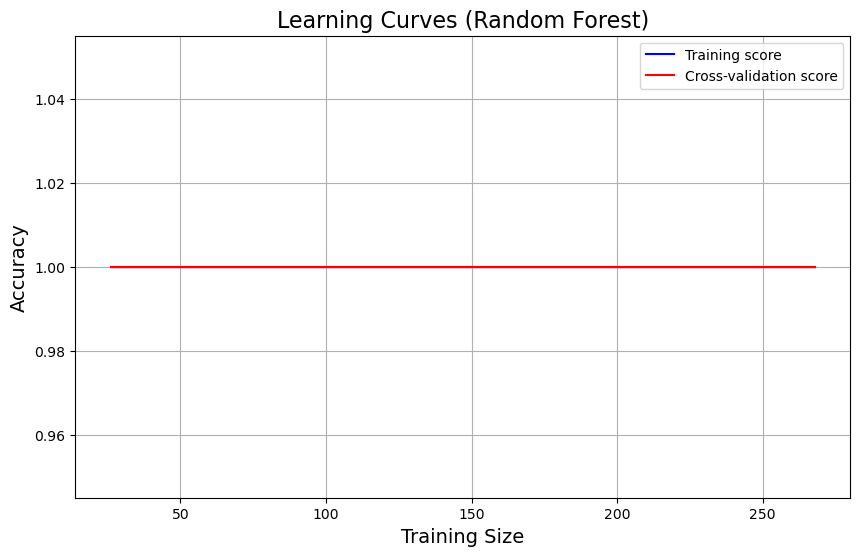

In [ ]:
from sklearn.model_selection import learning_curve


model = RandomForestClassifier(random_state=42)

# Compute learning curves
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate the mean and standard deviation of the scores
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotting the learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='blue', label='Training score')
plt.plot(train_sizes, test_mean, color='red', label='Cross-validation score')

# Fill between the standard deviations
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='red')

# Labels and title
plt.title('Learning Curves (Random Forest)', fontsize=16)
plt.xlabel('Training Size', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(loc='best')
plt.grid(True)
plt.show()


## “Using data, we’re not just predicting genres – we’re curating experiences.”